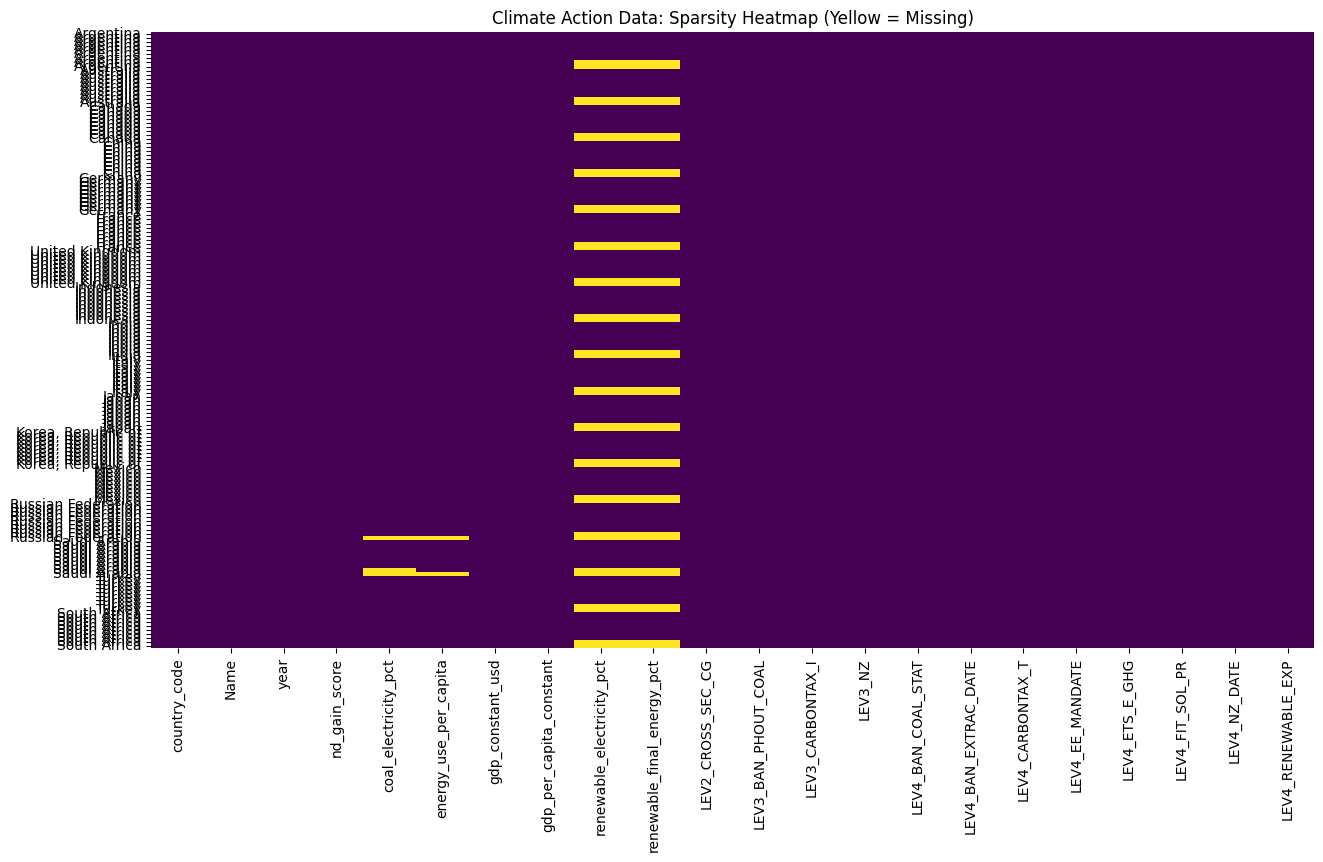

--- Column-wise Missing % ---
renewable_electricity_pct     22.222222
renewable_final_energy_pct    22.222222
coal_electricity_pct           1.960784
energy_use_per_capita          1.307190
dtype: float64

--- Top 5 Countries with Missing Data ---
Name
Saudi Arabia          3.703704
Russian Federation    3.174603
Argentina             2.116402
Japan                 2.116402
Turkey                2.116402
dtype: float64


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('../../data/processed/merged_dataset.csv')
# Remove USA and BRA
df = df[~df['Name'].isin(['United States', 'Brazil'])]


# Calculate the percentage of missing data per column
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

# Calculate missingness per country
country_missing = df.groupby('Name').apply(lambda x: x.isnull().mean().mean() * 100)

# Visualization
plt.figure(figsize=(15, 8))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=df['Name'])
plt.title('Climate Action Data: Sparsity Heatmap (Yellow = Missing)')
plt.show()

print("--- Column-wise Missing % ---")
print(missing_pct[missing_pct > 0])

print("\n--- Top 5 Countries with Missing Data ---")
print(country_missing.sort_values(ascending=False).head(5))

 

